# TimesFM 2.5: Time Series Forecasting with Transformers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/timesfm2_5.ipynb)

[TimesFM 2.5](https://huggingface.co/google/timesfm-2.5-200m-transformers) is a pretrained time-series foundation model from Google Research. It provides accurate zero-shot forecasts across different domains, forecasting horizons, and temporal granularities.

This notebook demonstrates:
1. **Zero-shot forecasting** on synthetic and real-world time series
2. **Quantile (probabilistic) predictions** with uncertainty estimation
3. **Attention backend comparison** (eager, SDPA, Flash Attention 2/3, Flex Attention)
4. **Fine-tuning with PEFT (LoRA)** on a custom dataset
5. **Forecasting with exogenous covariates** using in-context linear regression (XReg)

Key advantages of using TimesFM 2.5 via Transformers:
- Native support for all attention backends (SDPA, Flash Attention 2, Flex Attention) through the standard `attn_implementation` API
- Standard `from_pretrained` / `save_pretrained` workflow
- Easy fine-tuning with PEFT adapters (LoRA, QLoRA, etc.)
- Compatible with the broader Transformers ecosystem

## Setup

Install the required packages. We need the latest `transformers` from main for TimesFM 2.5 support.

In [ ]:
%pip install -q git+https://github.com/huggingface/transformers.git kernels accelerate peft matplotlib pandas pyarrow scikit-learn

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from transformers import TimesFm2_5ModelForPrediction

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Zero-Shot Forecasting

TimesFM 2.5 can forecast time series out-of-the-box without any training. Let's load the pretrained model and run inference on some synthetic signals.

In [2]:
model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    device_map=device,
)
model.eval()
print(f"Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Horizon length: {model.config.horizon_length}")
print(f"Context length: {model.config.context_length}")
print(f"Quantiles: {model.config.quantiles}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Model loaded with 231,289,280 parameters
Horizon length: 128
Context length: 16384
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


### Forecasting synthetic signals

The model accepts a list of 1D tensors as input (variable-length time series) and returns:
- `mean_predictions`: point forecasts of shape `(batch_size, horizon_length)`
- `full_predictions`: quantile forecasts of shape `(batch_size, horizon_length, num_quantiles)`

In [3]:
# Create synthetic time series of different lengths
t1 = np.linspace(0, 20, 200)
t2 = np.linspace(0, 10, 300)
t3 = np.linspace(0, 15, 400)

signals = {
    "Sine wave": np.sin(t1),
    "Trend + seasonality": 0.05 * t2 + np.sin(2 * np.pi * t2 / 50),
    "Damped oscillation": np.exp(-0.01 * t3) * np.sin(t3),
}

past_values = [
    torch.tensor(s, dtype=torch.float32, device=device) for s in signals.values()
]

with torch.no_grad():
    outputs = model(past_values=past_values)

print(f"Mean predictions shape: {outputs.mean_predictions.shape}")
print(f"Full predictions shape: {outputs.full_predictions.shape}")

Mean predictions shape: torch.Size([3, 128])
Full predictions shape: torch.Size([3, 128, 10])


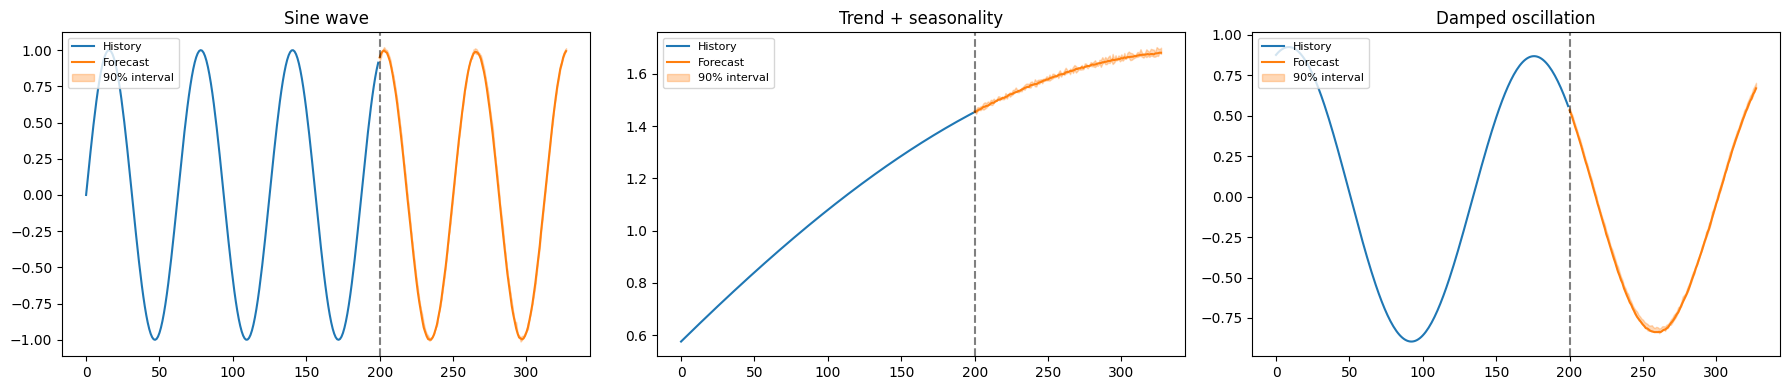

In [4]:
def plot_forecasts(signals, outputs, horizon_length, quantile_idx_low=0, quantile_idx_high=-1, history_length=200):
    """Plot historical data with forecasts and prediction intervals."""
    fig, axes = plt.subplots(1, len(signals), figsize=(6 * len(signals), 4))
    if len(signals) == 1:
        axes = [axes]

    mean_preds = outputs.mean_predictions.cpu().numpy()
    full_preds = outputs.full_predictions.cpu().numpy()

    for idx, (name, signal) in enumerate(signals.items()):
        ax = axes[idx]
        context = signal[-history_length:]
        forecast = mean_preds[idx, :horizon_length]
        q_low = full_preds[idx, :horizon_length, quantile_idx_low]
        q_high = full_preds[idx, :horizon_length, quantile_idx_high]

        t_hist = np.arange(len(context))
        t_pred = np.arange(len(context), len(context) + horizon_length)

        ax.plot(t_hist, context, label="History", color="tab:blue")
        ax.plot(t_pred, forecast, label="Forecast", color="tab:orange")
        ax.fill_between(t_pred, q_low, q_high, alpha=0.3, color="tab:orange", label="90% interval")
        ax.axvline(x=len(context), color="black", linestyle="--", alpha=0.5)
        ax.set_title(name)
        ax.legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


plot_forecasts(signals, outputs, model.config.horizon_length)

### Forecasting real-world data

Let's try the model on the Electricity Transformer Temperature (ETTh1) dataset, a commonly used benchmark for time series forecasting.

In [5]:
# Load ETTh1 dataset
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url, parse_dates=["date"])
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


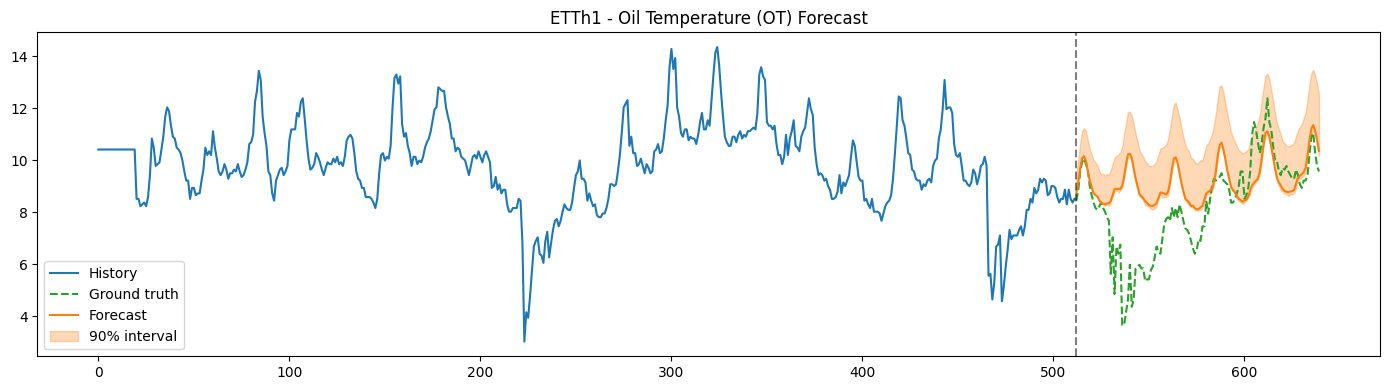

MAE: 1.3000


In [6]:
# Forecast the "OT" (Oil Temperature) column
target_col = "OT"
context_len = 512
horizon = model.config.horizon_length

# Use last context_len + horizon points: context for input, horizon for ground truth
ts = df[target_col].values
context = ts[-(context_len + horizon):-horizon]
ground_truth = ts[-horizon:]

past_values = [torch.tensor(context, dtype=torch.float32, device=device)]

with torch.no_grad():
    outputs = model(past_values=past_values)

forecast = outputs.mean_predictions[0].cpu().numpy()
full_preds = outputs.full_predictions[0].cpu().numpy()

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
t_hist = np.arange(context_len)
t_pred = np.arange(context_len, context_len + horizon)

ax.plot(t_hist, context, label="History", color="tab:blue")
ax.plot(t_pred, ground_truth, label="Ground truth", color="tab:green", linestyle="--")
ax.plot(t_pred, forecast, label="Forecast", color="tab:orange")
ax.fill_between(t_pred, full_preds[:, 0], full_preds[:, -1], alpha=0.3, color="tab:orange", label="90% interval")
ax.axvline(x=context_len, color="black", linestyle="--", alpha=0.5)
ax.set_title(f"ETTh1 - Oil Temperature ({target_col}) Forecast")
ax.legend()
plt.tight_layout()
plt.show()

# Compute MAE
mae = np.abs(forecast - ground_truth).mean()
print(f"MAE: {mae:.4f}")

### Batch forecasting multiple columns

TimesFM 2.5 accepts a list of variable-length time series, making it easy to forecast multiple series at once.

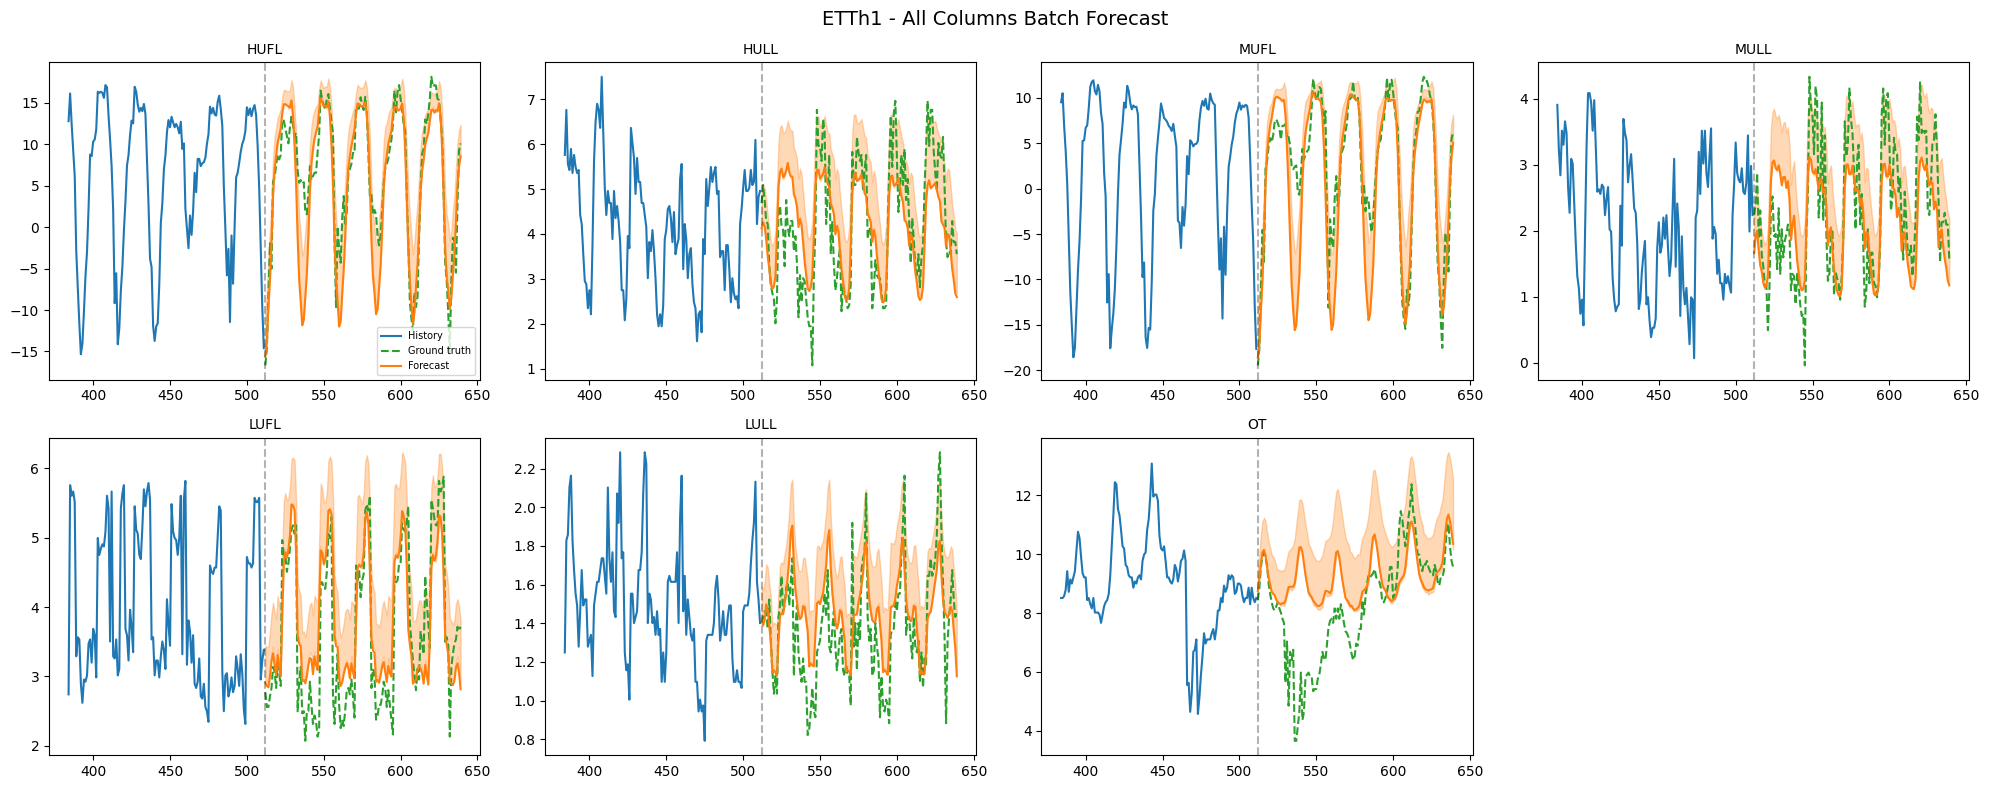

In [7]:
# Forecast all 7 columns of ETTh1 in a single batch
ts_cols = [c for c in df.columns if c != "date"]

past_values = []
ground_truths = []
for col in ts_cols:
    ts = df[col].values
    past_values.append(torch.tensor(ts[-(context_len + horizon):-horizon], dtype=torch.float32, device=device))
    ground_truths.append(ts[-horizon:])

with torch.no_grad():
    outputs = model(past_values=past_values)

# Plot all forecasts
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, col in enumerate(ts_cols):
    ax = axes[idx]
    forecast = outputs.mean_predictions[idx].cpu().numpy()
    full_preds = outputs.full_predictions[idx].cpu().numpy()
    gt = ground_truths[idx]

    t_hist = np.arange(context_len)
    t_pred = np.arange(context_len, context_len + horizon)

    ax.plot(t_hist[-128:], past_values[idx].cpu().numpy()[-128:], label="History", color="tab:blue")
    ax.plot(t_pred, gt, label="Ground truth", color="tab:green", linestyle="--")
    ax.plot(t_pred, forecast, label="Forecast", color="tab:orange")
    ax.fill_between(t_pred, full_preds[:, 0], full_preds[:, -1], alpha=0.3, color="tab:orange")
    ax.axvline(x=context_len, color="black", linestyle="--", alpha=0.3)
    ax.set_title(col, fontsize=10)
    if idx == 0:
        ax.legend(fontsize=7)

# Hide the last empty subplot
axes[-1].set_visible(False)
plt.suptitle("ETTh1 - All Columns Batch Forecast", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Attention Backend Comparison

One of the key benefits of using TimesFM 2.5 via Transformers is native support for different attention implementations:
- **Eager**: Standard PyTorch attention (baseline)
- **SDPA**: PyTorch's `scaled_dot_product_attention` (fused kernels)
- **Flash Attention 2**: Memory-efficient attention via `kernels-community/flash-attn2`
- **Flash Attention 3**: Latest Flash Attention via `kernels-community/flash-attn3`
- **Flex Attention**: PyTorch's `flex_attention` with `torch.compile` (first call incurs a one-time compilation cost)

All backends produce numerically equivalent outputs but differ in speed and memory usage. We benchmark each on a batch of 8 series of length 2048.

In [ ]:
import time

# Prepare a batch of longer sequences for benchmarking
benchmark_input = [
    torch.tensor(np.sin(np.linspace(0, 20, 2048)), dtype=torch.float32, device=device)
    for _ in range(8)
]

backends = ["eager", "sdpa", "kernels-community/flash-attn2", "kernels-community/flash-attn3", "flex_attention"]

results = {}

for backend in backends:
    print(f"\nLoading model with attn_implementation='{backend}'...")
    m = TimesFm2_5ModelForPrediction.from_pretrained(
        "google/timesfm-2.5-200m-transformers",
        attn_implementation=backend,
        torch_dtype=torch.bfloat16,
        device_map=device,
    )
    m.eval()

    # Warmup: use the same input as the benchmark so that any torch.compile
    # tracing (e.g. for flex_attention) is fully completed before we start timing.
    with torch.no_grad():
        for _ in range(3):
            _ = m(past_values=benchmark_input)

    # Benchmark
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    n_runs = 5
    with torch.no_grad():
        for _ in range(n_runs):
            out = m(past_values=benchmark_input)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - start) / n_runs

    results[backend] = {
        "time_ms": elapsed * 1000,
        "predictions": out.mean_predictions.float().cpu(),
    }
    print(f"  {backend}: {elapsed*1000:.1f} ms/batch")
    del m
    if device == "cuda":
        torch.cuda.empty_cache()

Max diff (eager vs sdpa): 5.47e-03
Max diff (eager vs kernels-community/flash-attn2): 5.47e-03
Max diff (eager vs kernels-community/flash-attn3): 5.47e-03
Max diff (eager vs flex_attention): 5.47e-03


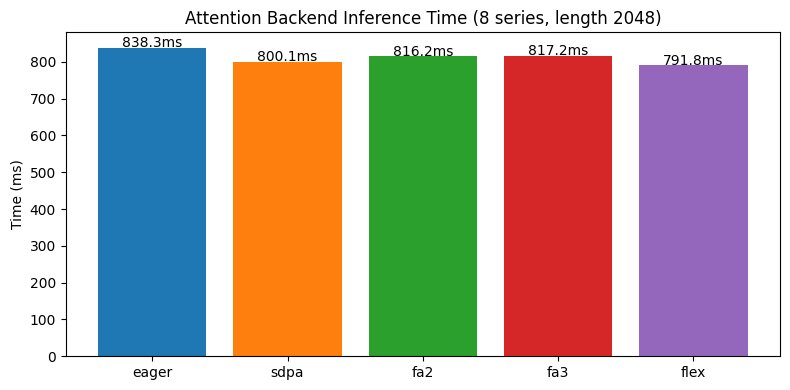

In [11]:
# Verify numerical equivalence between backends
reference = results["eager"]["predictions"]
for backend, data in results.items():
    if backend == "eager":
        continue
    diff = (reference - data["predictions"]).abs().max().item()
    print(f"Max diff (eager vs {backend}): {diff:.2e}")

# Plot timing comparison
fig, ax = plt.subplots(figsize=(8, 4))
backend_names = list(results.keys())
display_names = {
    "eager": "eager",
    "sdpa": "sdpa",
    "kernels-community/flash-attn2": "fa2",
    "kernels-community/flash-attn3": "fa3",
    "flex_attention": "flex",
}
labels = [display_names.get(b, b) for b in backend_names]
times = [results[b]["time_ms"] for b in backend_names]
bars = ax.bar(labels, times, color=["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"][:len(backend_names)])
ax.set_ylabel("Time (ms)")
ax.set_title("Attention Backend Inference Time (8 series, length 2048)")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f"{t:.1f}ms", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Fine-Tuning with PEFT (LoRA)

TimesFM 2.5 can be fine-tuned on custom datasets using parameter-efficient methods like LoRA. This is especially useful when you have domain-specific data and want to adapt the model without updating all 200M parameters.

We'll fine-tune on a retail demand forecasting dataset (weekly store sales), the same dataset used in the [Chronos-2 quickstart notebook](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb). The goal is to forecast the next 13 weeks of sales for each store.

In [8]:
from torch.utils.data import Dataset, DataLoader
from peft import LoraConfig, get_peft_model


class TimeSeriesRandomWindowDataset(Dataset):
    """Random window dataset for time series fine-tuning.

    Pre-samples random (series, split-point) windows similar to Chronos-2's
    random slicing. Each window has a full context_len context (no zero-padding)
    to avoid corrupting TimesFM's internal RevIN normalization statistics.

    No external normalization is needed — TimesFM handles instance normalization
    internally. The loss will be in the original data scale.
    """

    def __init__(self, series_list, context_len, horizon_len, num_samples=10000):
        self.series_list = series_list
        self.context_len = context_len
        self.horizon_len = horizon_len
        self.samples = []
        for _ in range(num_samples):
            idx = np.random.randint(len(series_list))
            ts = series_list[idx]
            split = np.random.randint(context_len, len(ts) - horizon_len + 1)
            self.samples.append((idx, split))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        idx, split = self.samples[i]
        ts = self.series_list[idx]
        context = ts[split - self.context_len : split]
        target = ts[split : split + self.horizon_len]
        return torch.tensor(context, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)


class TimeSeriesLastWindowDataset(Dataset):
    """Returns the last window from each time series (for validation)."""

    def __init__(self, series_list, context_len, horizon_len):
        self.items = []
        for ts in series_list:
            if len(ts) >= context_len + horizon_len:
                ctx = ts[-(context_len + horizon_len) : -horizon_len]
                tgt = ts[-horizon_len:]
                self.items.append((torch.tensor(ctx, dtype=torch.float32), torch.tensor(tgt, dtype=torch.float32)))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

In [9]:
# Load the retail sales dataset (same as Chronos-2 quickstart)
sales_train_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet"
)
sales_test_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet"
)

target = "Sales"
horizon_len = 13  # 13 weeks (one quarter)
# context_len must be a multiple of patch_length (32).
# Each store has 120 weekly data points, so we use 64 (~1.2 years).
context_len = 64

print(f"Train shape: {sales_train_df.shape}, Test shape: {sales_test_df.shape}")
print(f"Number of stores: {sales_train_df['id'].nunique()}")
print(f"Data points per store: {sales_train_df.groupby('id').size().iloc[0]}")
display(sales_train_df.head())

# Note: We do NOT normalize the data externally. TimesFM 2.5 applies its own
# internal instance normalization (RevIN) and its loss is computed on
# denormalized predictions vs raw future_values.

# Collect all store series (must be long enough for context + horizon)
all_series = []
for store_id, group in sales_train_df.groupby("id"):
    sales = group[target].values.astype(np.float32)
    if len(sales) >= context_len + horizon_len:
        all_series.append(sales)

print(f"Valid stores: {len(all_series)} (need >= {context_len + horizon_len} data points)")

# Train: pre-sample random windows (like Chronos-2's random slicing)
# Val: last window from each store
train_dataset = TimeSeriesRandomWindowDataset(all_series, context_len, horizon_len, num_samples=5000)
val_dataset = TimeSeriesLastWindowDataset(all_series, context_len, horizon_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val windows: {len(val_dataset)}")

Train shape: (133800, 8), Test shape: (14495, 7)
Number of stores: 1115
Data points per store: 120


,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0
3,1,2013-02-03,28693.0,0.857143,0.000000,0.0,0.0,3561.0
4,1,2013-02-10,35771.0,0.857143,0.714286,0.0,0.0,4094.0


Valid stores: 1115 (need >= 77 data points)
Train samples: 5000, Val windows: 1115


In [10]:
# Load a fresh model for fine-tuning
ft_model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    torch_dtype=torch.bfloat16,
    device_map=device,
)

# Apply LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules="all-linear",
    lora_dropout=0.05,
    bias="none",
)

ft_model = get_peft_model(ft_model, lora_config)
ft_model.print_trainable_parameters()

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

trainable params: 1,382,912 || all params: 232,672,192 || trainable%: 0.5944


In [11]:
# Training loop
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=1e-4, weight_decay=0.01)
num_epochs = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs * len(train_loader))
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    ft_model.train()
    epoch_train_loss = 0
    n_batches = 0
    for context, target_vals in train_loader:
        context, target_vals = context.to(device), target_vals.to(device)

        outputs = ft_model(past_values=context, future_values=target_vals, forecast_context_len=context_len)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()

        epoch_train_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validate
    ft_model.eval()
    epoch_val_loss = 0
    n_val_batches = 0
    with torch.no_grad():
        for val_context, val_target in val_loader:
            val_context, val_target = val_context.to(device), val_target.to(device)
            val_out = ft_model(past_values=val_context, future_values=val_target, forecast_context_len=context_len)
            epoch_val_loss += val_out.loss.item()
            n_val_batches += 1

    avg_val_loss = epoch_val_loss / n_val_batches
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        ft_model.save_pretrained("timesfm2_5-retail-lora")

    print(f"Epoch {epoch+1}/{num_epochs} ({n_batches} steps) - Train loss: {avg_train_loss:.4f}, Val loss: {avg_val_loss:.4f}")

Epoch 1/20 (157 steps) - Train loss: 1.8673, Val loss: 0.3481
Epoch 2/20 (157 steps) - Train loss: 1.2732, Val loss: 0.3238
Epoch 3/20 (157 steps) - Train loss: 1.0454, Val loss: 0.2815
Epoch 4/20 (157 steps) - Train loss: 0.8334, Val loss: 0.2682
Epoch 5/20 (157 steps) - Train loss: 0.6838, Val loss: 0.2541
Epoch 6/20 (157 steps) - Train loss: 0.5916, Val loss: 0.2480
Epoch 7/20 (157 steps) - Train loss: 0.5343, Val loss: 0.2394
Epoch 8/20 (157 steps) - Train loss: 0.4679, Val loss: 0.2379
Epoch 9/20 (157 steps) - Train loss: 0.4205, Val loss: 0.2347
Epoch 10/20 (157 steps) - Train loss: 0.3841, Val loss: 0.2286
Epoch 11/20 (157 steps) - Train loss: 0.3524, Val loss: 0.2257
Epoch 12/20 (157 steps) - Train loss: 0.3329, Val loss: 0.2234
Epoch 13/20 (157 steps) - Train loss: 0.3120, Val loss: 0.2201
Epoch 14/20 (157 steps) - Train loss: 0.2991, Val loss: 0.2194
Epoch 15/20 (157 steps) - Train loss: 0.2888, Val loss: 0.2185
Epoch 16/20 (157 steps) - Train loss: 0.2826, Val loss: 0.2180
E

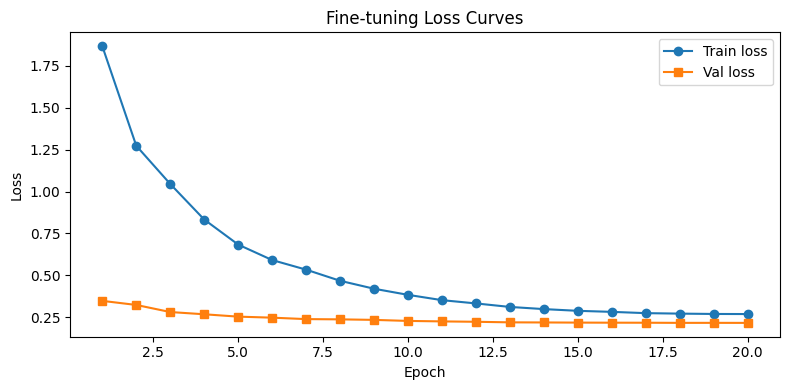

In [12]:
# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train loss", marker="o")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="Val loss", marker="s")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Fine-tuning Loss Curves")
ax.legend()
plt.tight_layout()
plt.show()

### Compare zero-shot vs fine-tuned

Let's compare the zero-shot model with the LoRA fine-tuned model on the held-out test set for a few stores.

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

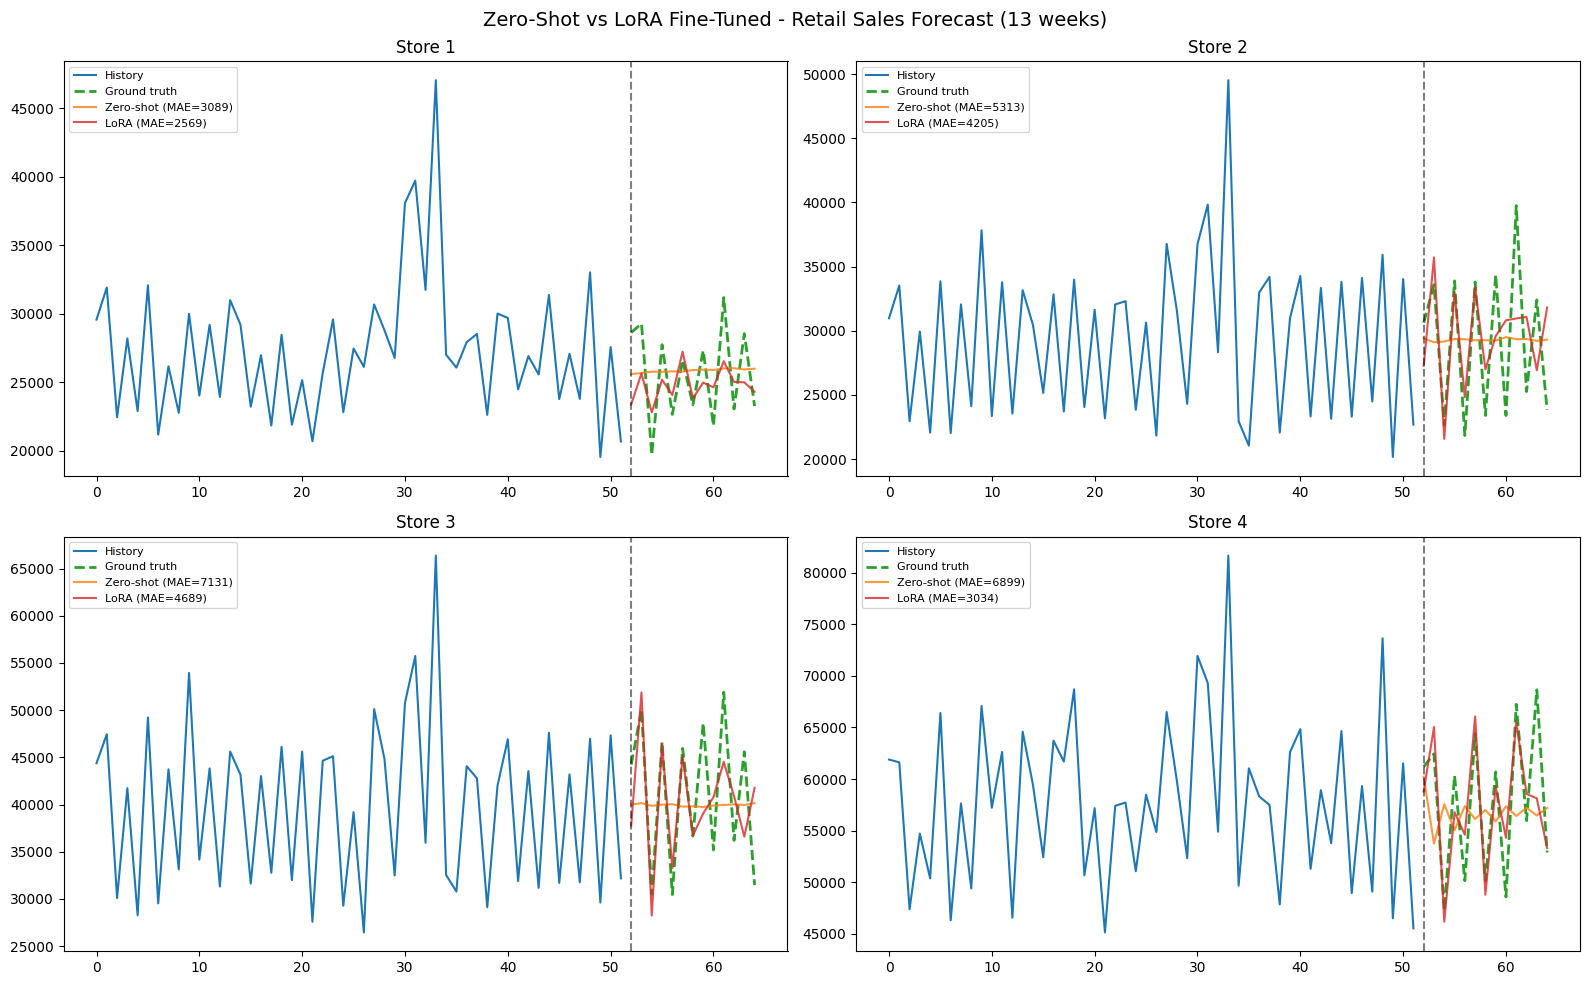

Average zero-shot MAE: 5608.10
Average LoRA MAE:      3624.42
Improvement:           35.4%


In [13]:
# Evaluate zero-shot vs fine-tuned on the test set
base_model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    torch_dtype=torch.bfloat16,
    device_map=device,
)
base_model.eval()

# Pick a few stores to visualize
store_ids = ["1", "2", "3", "4"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

base_maes, ft_maes = [], []

for idx, store_id in enumerate(store_ids):
    store_train = sales_train_df[sales_train_df["id"] == store_id][target].values.astype(np.float32)
    store_test = sales_test_df[sales_test_df["id"] == store_id][target].values.astype(np.float32)
    ground_truth = store_test[:horizon_len]

    # Both models get raw data — TimesFM normalizes internally
    test_input = [torch.tensor(store_train[-context_len:], dtype=torch.float32, device=device)]

    with torch.no_grad():
        base_out = base_model(past_values=test_input)
        ft_out = ft_model(past_values=test_input)

    base_forecast = base_out.mean_predictions[0, :horizon_len].float().cpu().numpy()
    ft_forecast = ft_out.mean_predictions[0, :horizon_len].float().cpu().numpy()

    base_mae = np.abs(base_forecast - ground_truth).mean()
    ft_mae = np.abs(ft_forecast - ground_truth).mean()
    base_maes.append(base_mae)
    ft_maes.append(ft_mae)

    # Plot
    ax = axes[idx]
    history = store_train[-52:]
    t_hist = np.arange(len(history))
    t_pred = np.arange(len(history), len(history) + horizon_len)

    ax.plot(t_hist, history, label="History", color="tab:blue")
    ax.plot(t_pred, ground_truth, label="Ground truth", color="tab:green", linestyle="--", linewidth=2)
    ax.plot(t_pred, base_forecast, label=f"Zero-shot (MAE={base_mae:.0f})", color="tab:orange", alpha=0.8)
    ax.plot(t_pred, ft_forecast, label=f"LoRA (MAE={ft_mae:.0f})", color="tab:red", alpha=0.8)
    ax.axvline(x=len(history), color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Store {store_id}")
    ax.legend(fontsize=8)

plt.suptitle("Zero-Shot vs LoRA Fine-Tuned - Retail Sales Forecast (13 weeks)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Average zero-shot MAE: {np.mean(base_maes):.2f}")
print(f"Average LoRA MAE:      {np.mean(ft_maes):.2f}")
print(f"Improvement:           {(np.mean(base_maes) - np.mean(ft_maes)) / np.mean(base_maes) * 100:.1f}%")

### Loading and reusing a saved LoRA adapter

The LoRA adapter weights can be saved and loaded separately from the base model, making them easy to share and version.

In [14]:
from peft import PeftModel

# Load base model + LoRA adapter
base = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    torch_dtype=torch.bfloat16,
    device_map=device,
)
loaded_model = PeftModel.from_pretrained(base, "timesfm2_5-retail-lora")
loaded_model.eval()

# Verify with one store
store_train = sales_train_df[sales_train_df["id"] == "1"][target].values.astype(np.float32)
test_input = [torch.tensor(store_train[-context_len:], dtype=torch.float32, device=device)]

with torch.no_grad():
    ft_out = ft_model(past_values=test_input)
    loaded_out = loaded_model(past_values=test_input)

diff = (ft_out.mean_predictions.float() - loaded_out.mean_predictions.float()).abs().max().item()
print(f"Max diff between saved and loaded adapter: {diff:.2e}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Max diff between saved and loaded adapter: 0.00e+00


## 4. Forecasting with Exogenous Covariates (XReg)

TimesFM 2.5 can incorporate **exogenous covariates** (known future variables) to improve forecasts using a **post-hoc in-context linear regression** approach ([xreg_lib](https://github.com/google/timesfm)):

1. Fit a ridge regression on the context: `target ~ covariates`
2. Subtract the regression fit from the context to get residuals
3. Feed the residuals to TimesFM for forecasting
4. Combine: `final_forecast = regression_horizon_prediction + TimesFM_residual_forecast`

This works best when covariates have an **approximately linear** relationship with the target (e.g., price → sales, marketing spend → demand). For complex nonlinear relationships (e.g., temperature → electricity load), neural approaches like [Toto](https://github.com/ServiceNow/context-is-key-forecasting) that pass covariates through the network are more appropriate.

We demonstrate this using a synthetic retail demand dataset with a known price effect, adapted from the [TimesFM covariates PR](https://github.com/huggingface/transformers/pull/40755).

Generated 4 series, each 640 points
Context: 512, Horizon: 128
Price sensitivity per series: [8, 10, 12, 14]


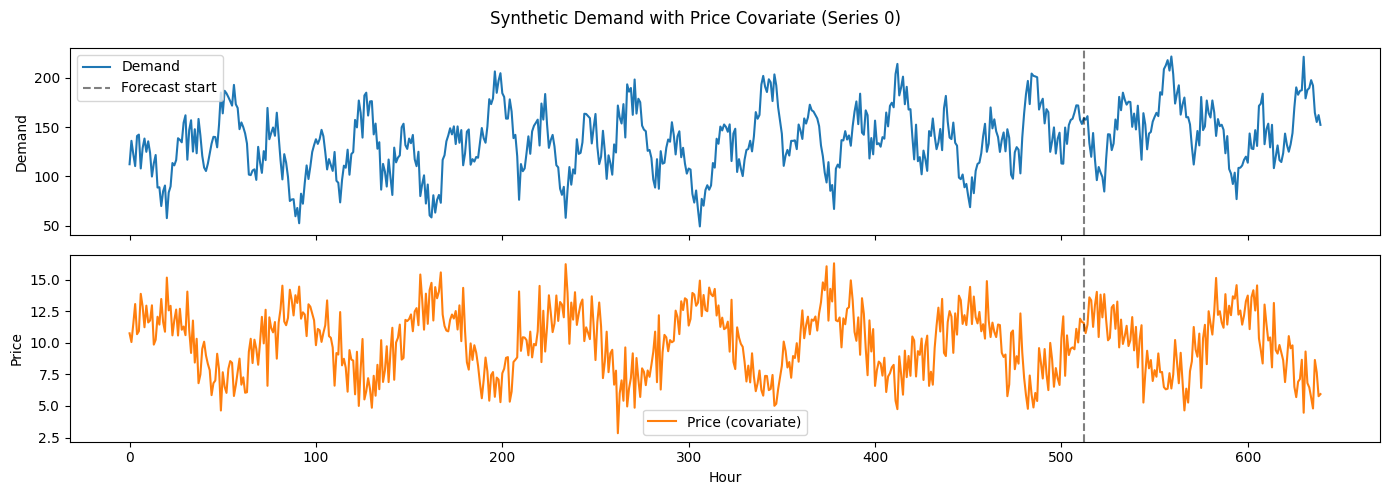

In [19]:
# Generate synthetic retail demand with a known price effect
# demand = seasonal_pattern + trend - price_sensitivity * price + noise
np.random.seed(42)

n_series = 4
context_len_xreg = 512  # must be multiple of 32
horizon_xreg = 128      # model's max horizon

series_data = []
price_data = []

for s in range(n_series):
    total_len = context_len_xreg + horizon_xreg
    t = np.arange(total_len)

    # Base pattern: daily seasonality + slight upward trend
    base = 200 + 0.05 * t + 30 * np.sin(2 * np.pi * t / 24) + 10 * np.sin(2 * np.pi * t / (24 * 7))

    # Price: varies between 5-15, with known future values
    price = 10 + 3 * np.sin(2 * np.pi * t / (24 * 3)) + np.random.randn(total_len) * 1.5

    # Strong linear price effect: higher price → lower demand
    price_sensitivity = 8.0 + s * 2  # varies per series
    demand = base - price_sensitivity * price + np.random.randn(total_len) * 5

    series_data.append(demand.astype(np.float32))
    price_data.append(price.astype(np.float32))

print(f"Generated {n_series} series, each {context_len_xreg + horizon_xreg} points")
print(f"Context: {context_len_xreg}, Horizon: {horizon_xreg}")
print(f"Price sensitivity per series: {[8 + s*2 for s in range(n_series)]}")

# Show one example
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(series_data[0], label="Demand")
ax1.axvline(x=context_len_xreg, color="black", linestyle="--", alpha=0.5, label="Forecast start")
ax1.set_ylabel("Demand")
ax1.legend()
ax2.plot(price_data[0], label="Price (covariate)", color="tab:orange")
ax2.axvline(x=context_len_xreg, color="black", linestyle="--", alpha=0.5)
ax2.set_ylabel("Price")
ax2.set_xlabel("Hour")
ax2.legend()
plt.suptitle("Synthetic Demand with Price Covariate (Series 0)")
plt.tight_layout()
plt.show()

In [16]:
def forecast_with_covariates(
    model,
    past_values,
    dynamic_numerical_covariates,
    forecast_context_len=None,
    ridge=0.0,
    normalize_xreg_target=True,
):
    """Forecast with exogenous covariates using 'xreg + timesfm' mode.

    1. Fit ridge regression: target ~ covariates (on context)
    2. Subtract regression fit from context → residuals
    3. Feed residuals to TimesFM → residual forecast
    4. Final = regression horizon prediction + residual forecast

    This is the default mode from TimesFM's xreg_lib. It works well when
    covariates have an approximately linear relationship with the target.
    """
    device = past_values[0].device
    fcontext_len = forecast_context_len or model.config.context_length
    max_horizon = model.config.horizon_length

    # Convert to numpy for xreg processing
    inputs = [ts[-fcontext_len:].cpu().float().numpy() for ts in past_values]
    train_lens = [len(inp) for inp in inputs]

    # Split dynamic covariates into context (train) and horizon (test)
    train_dyn_num, test_dyn_num = {}, {}
    test_lens = []
    for cov_name, cov_values in dynamic_numerical_covariates.items():
        train_dyn_num[cov_name] = []
        test_dyn_num[cov_name] = []
        for i, (inp, cov) in enumerate(zip(inputs, cov_values)):
            input_len = len(inp)
            train_dyn_num[cov_name].append(cov[:input_len])
            test_dyn_num[cov_name].append(cov[input_len:])
            if cov_name == list(dynamic_numerical_covariates.keys())[0]:
                test_lens.append(len(cov) - input_len)

    # Prepare targets (optionally normalized)
    targets = [inp.tolist() for inp in inputs]
    per_instance_stats = None
    if normalize_xreg_target:
        targets, per_instance_stats = xreg_normalize(targets)

    # Fit ridge regression with debug_info to get context predictions too
    xreg = BatchedInContextXRegLinear(
        targets=targets,
        train_lens=train_lens,
        test_lens=test_lens,
        train_dynamic_numerical_covariates=train_dyn_num,
        test_dynamic_numerical_covariates=test_dyn_num,
    )
    xreg_horizon_preds, xreg_context_preds = xreg.fit(
        ridge=ridge,
        one_hot_encoder_drop=None if ridge > 0 else "first",
        debug_info=True,
    )

    # Compute residuals = target - xreg_context_fit, then feed to TimesFM
    residual_inputs = []
    for target, xreg_ctx in zip(targets, xreg_context_preds):
        residual = np.array(target) - np.array(xreg_ctx)
        residual_inputs.append(torch.tensor(residual, dtype=torch.bfloat16, device=device))

    with torch.no_grad():
        residual_output = model(past_values=residual_inputs, forecast_context_len=fcontext_len)

    # Combine: xreg_horizon + timesfm_residual_forecast, then denormalize
    combined = []
    for i, tl in enumerate(test_lens):
        effective_len = min(tl, max_horizon)
        timesfm_residual = residual_output.mean_predictions[i, :effective_len].float().cpu().numpy()
        xreg_h = np.array(xreg_horizon_preds[i][:effective_len])

        combined_pred = xreg_h + timesfm_residual
        if normalize_xreg_target and per_instance_stats:
            mu, sigma = per_instance_stats[i]
            combined_pred = combined_pred * sigma + mu
        combined.append(combined_pred)

    return combined, xreg_horizon_preds, residual_output

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

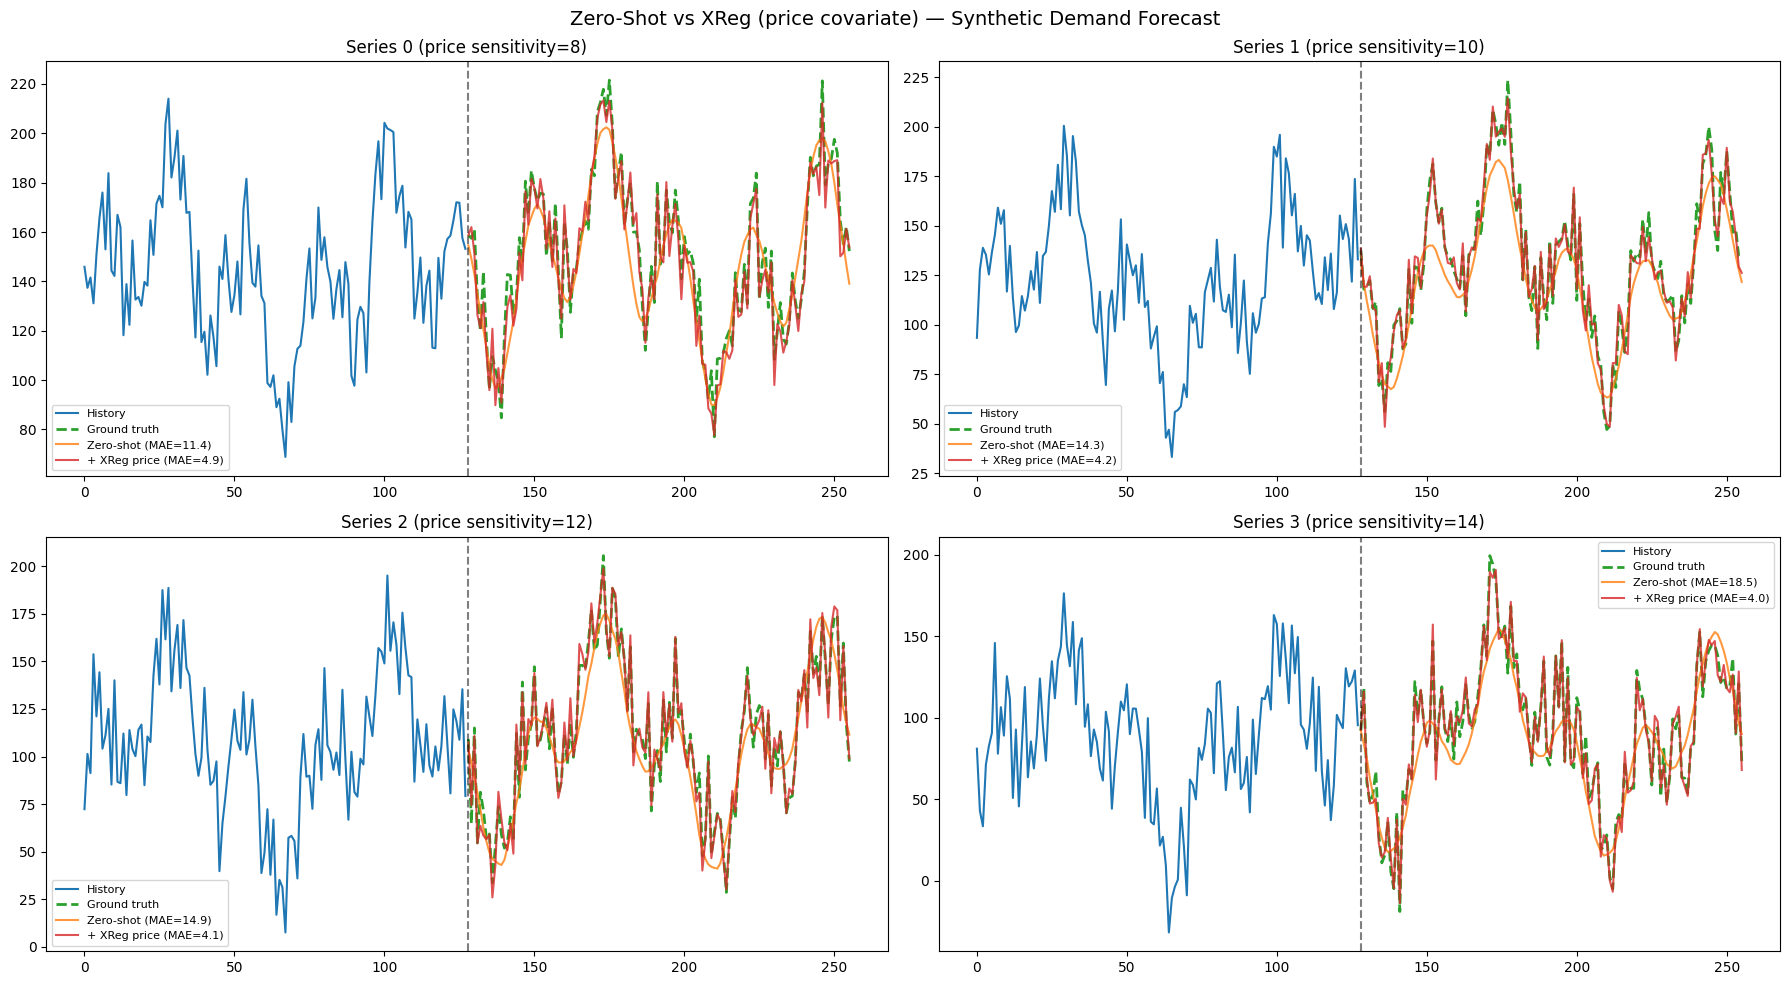

Average zero-shot MAE: 14.78
Average XReg MAE:      4.32
Improvement:           70.8%


In [18]:
# Load model for xreg comparison
xreg_model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    torch_dtype=torch.bfloat16,
    device_map=device,
)
xreg_model.eval()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

base_maes, xreg_maes = [], []

for s in range(n_series):
    demand = series_data[s]
    price = price_data[s]

    context = demand[:context_len_xreg]
    ground_truth = demand[context_len_xreg:]
    # Covariates span context + horizon
    full_price = price[:context_len_xreg + horizon_xreg].tolist()

    past = [torch.tensor(context, dtype=torch.float32, device=device)]

    # Zero-shot (no covariates)
    with torch.no_grad():
        base_out = xreg_model(past_values=past, forecast_context_len=context_len_xreg)
    base_forecast = base_out.mean_predictions[0, :horizon_xreg].float().cpu().numpy()

    # With covariates (xreg + timesfm)
    combined_preds, _, _ = forecast_with_covariates(
        xreg_model,
        past_values=past,
        dynamic_numerical_covariates={"price": [full_price]},
        forecast_context_len=context_len_xreg,
        ridge=0.1,
    )
    xreg_forecast = combined_preds[0]

    base_mae = np.abs(base_forecast - ground_truth[:len(base_forecast)]).mean()
    xreg_mae = np.abs(xreg_forecast - ground_truth[:len(xreg_forecast)]).mean()
    base_maes.append(base_mae)
    xreg_maes.append(xreg_mae)

    # Plot
    ax = axes[s]
    history = context[-128:]
    t_hist = np.arange(len(history))
    t_pred = np.arange(len(history), len(history) + len(xreg_forecast))

    ax.plot(t_hist, history, label="History", color="tab:blue")
    ax.plot(t_pred, ground_truth[:len(xreg_forecast)], label="Ground truth", color="tab:green", linestyle="--", linewidth=2)
    ax.plot(t_pred, base_forecast[:len(xreg_forecast)], label=f"Zero-shot (MAE={base_mae:.1f})", color="tab:orange", alpha=0.8)
    ax.plot(t_pred, xreg_forecast, label=f"+ XReg price (MAE={xreg_mae:.1f})", color="tab:red", alpha=0.8)
    ax.axvline(x=len(history), color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Series {s} (price sensitivity={8 + s*2})")
    ax.legend(fontsize=8)

plt.suptitle("Zero-Shot vs XReg (price covariate) — Synthetic Demand Forecast", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Average zero-shot MAE: {np.mean(base_maes):.2f}")
print(f"Average XReg MAE:      {np.mean(xreg_maes):.2f}")
print(f"Improvement:           {(np.mean(base_maes) - np.mean(xreg_maes)) / np.mean(base_maes) * 100:.1f}%")

## Summary

In this notebook, we demonstrated the key capabilities of TimesFM 2.5 in Transformers:

- **Zero-shot forecasting**: The model provides accurate forecasts on unseen data without any training, including quantile uncertainty estimates.
- **Batch forecasting**: Multiple time series of different lengths can be forecast in a single call.
- **Attention backends**: Native support for eager, SDPA, Flash Attention 2/3, and Flex Attention, with numerically equivalent outputs and different performance characteristics.
- **PEFT fine-tuning**: LoRA adapters can be applied to adapt the model to domain-specific data (retail sales) with minimal trainable parameters.
- **Exogenous covariates (XReg)**: Known future variables (e.g., price) can be incorporated via in-context ridge regression to improve forecast accuracy without retraining. The linear regression can be extended with polynomial features (e.g., `price²`, `price³`) or interaction terms to capture non-linear covariate effects while keeping the closed-form solve. For highly non-linear relationships (e.g., temperature → electricity load), neural approaches like [Toto](https://github.com/ServiceNow/context-is-key-forecasting) that pass covariates through the network are more appropriate.

For more information, see:
- [Model card](https://huggingface.co/google/timesfm-2.5-200m-transformers)
- [Transformers documentation](https://huggingface.co/docs/transformers/model_doc/timesfm2_5)
- [Original paper](https://huggingface.co/papers/2310.10688)